# Function 2 Analysis - Week 3

This notebook contains the exploratory analysis for **Function 2** in Week 3. Our dataset now contains **12 datapoints** after incorporating the last two weeks' queries, including the strong results around (0.85, 0.25) and the new point from this week.

**Function Description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

**Approach:** This week, we implement **Bayesian Optimization** with a **diversity-aware selection strategy** to systematically explore the function space. Given the evidence of multiple local peaks in the data, we use:
- Gaussian Process surrogate model with Matérn kernel
- Upper Confidence Bound (UCB) acquisition function with **κ=10.0** (balanced exploration-exploitation)
- **Spatial diversity constraint** to ensure candidate points are spread across different regions rather than clustering in one area

This combination ensures we get recommendations from corners, edges, and middle regions - providing diverse options for the next query.


## 1. Loading and Displaying the Data

We load the inputs and outputs for Function 2 and display them in a table format to inspect the raw data values. Both x1 and x2 are normalized in [0,1]. 


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1 and Week 2 new points
X_new_point_week_1 = np.array([[0.850000, 0.250000]])
y_new_point_week_1 = np.array([0.4588155729748088])
X_new_point_week_2 = np.array([[0.535400, 0.505100]])
y_new_point_week_2 = np.array([0.4687657102198476])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
df


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**Data Summary:**
- We have 12 observations total (10 initial + 2 from the Week 1 and Week 2 queries)
- Output values range from approximately -0.57 to just under +0.47
- **New point (Week 1):** The point (0.85, 0.25) delivered a very strong score (y ≈ 0.459), confirming high potential in the high-x1, low-to-moderate-x2 region
- **New point (Week 2):** The point (0.5354, 0.5051) actually came back slightly higher (y ≈ 0.469) and sits more centrally in the input space, suggesting the high-value region may extend along a broader ridge rather than being a single isolated spike
- Overall, the pattern is still multi-modal and noisy, but the two best points give us a clear “band” of promising `(x1, x2)` combinations to explore further.

## 3. Manually Selected Recommendation for Week 3

Here we ignore the week-by-week labels and simply look at the **two highest `y` values in the full dataset**:
- Best point: approximately `(x1, x2) = (0.7026, 0.9266)`
- Second-best point: approximately `(x1, x2) = (0.6658, 0.1240)`

To propose a **simple, human-chosen recommendation for Week 3**, we take the straight line segment between these two best points and pick the location where **`x1 = 0.7`**. This gives us a point that truly lies between the top two observations in the `x1` direction, while still being slightly central in `x2`. This is still an **exploratory heuristic choice** rather than an optimisation result, but it cleanly interpolates between the globally best two points observed so far.


In [35]:
# Manual Week 3 recommendation: point on the line between the top two observations at x1 = 0.7
# Identify the two highest-y rows
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)

p1 = df_sorted.loc[0, ["x1", "x2"]].to_numpy()  # best point
p2 = df_sorted.loc[1, ["x1", "x2"]].to_numpy()  # second-best point

x1_target = 0.7
x2_target = p2[1]+(p1[1] - p2[1])/2

X_recommend_week_3 = np.array([[x1_target, x2_target]])
print("Top two observations (from df_sorted):")
print(df_sorted.head(2)[["x1", "x2", "y"]])
print(f"\nRecommended next query for Week 3 (manual choice): x1 = {x1_target:.3f}, x2 = {x2_target:.3f}")


Top two observations (from df_sorted):
         x1        x2         y
0  0.702637  0.926564  0.611205
1  0.665800  0.123969  0.538996

Recommended next query for Week 3 (manual choice): x1 = 0.700, x2 = 0.525


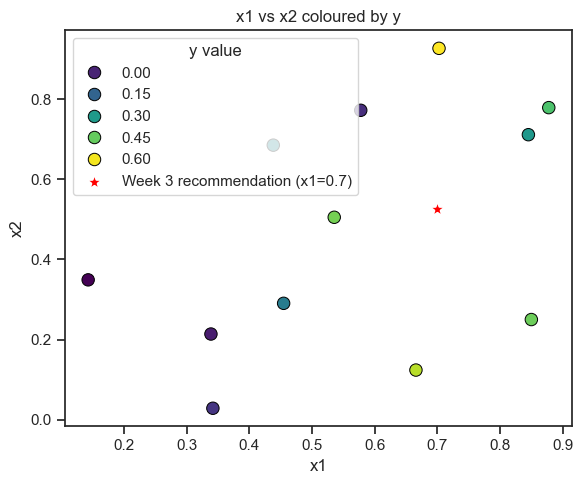

In [36]:
plt.figure(figsize=(6, 5))
scatter = sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="viridis", s=80, edgecolor="black")

# Overlay the manual Week 3 recommendation (if computed above)
try:
    plt.scatter(X_recommend_week_3[0, 0], X_recommend_week_3[0, 1],
                c="red", s=200, marker="*", edgecolor="white", linewidths=2,
                label="Week 3 recommendation (x1=0.7)")
except NameError:
    pass

plt.title("x1 vs x2 coloured by y")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="y value")
plt.tight_layout()
plt.show()
